# Elden Ring Reddit

THIS IS  ONLY THE Eldenring analysis!

Techniques included:
- Word clouds over time windows
- Topic modelling (NMF)
- Embedding projection (TF-IDF + SVD)
- Word co-occurrence network
- Sentiment analysis over time

In [ ]:
import re
from io import StringIO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import NMF, TruncatedSVD

# Optional libraries (fallbacks handled later)
try:
    from wordcloud import WordCloud
except Exception:
    WordCloud = None

try:
    import networkx as nx
except Exception:
    nx = None

# ---------- Load mixed CSV (Table A + Table B in one file) ----------
base_path = r"C:\Users\Kiskacsa\Documents\GHENT\smwa\házi"
file_path = f"{base_path}\\output_data_eldenring.csv"

with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
    raw = f.read()

if "===Table.A===" not in raw or "===Table.B===" not in raw:
    raise ValueError("Expected markers ===Table.A=== and ===Table.B=== were not found.")

table_a_block = raw.split("===Table.A===", 1)[1].split("===Table.B===", 1)[0].strip()
table_b_block = raw.split("===Table.B===", 1)[1].strip()

posts_df = pd.read_csv(StringIO(table_a_block))
comments_df = pd.read_csv(StringIO(table_b_block))

# ---------- Normalize columns ----------
posts_df.columns = [c.strip() for c in posts_df.columns]
comments_df.columns = [c.strip() for c in comments_df.columns]

posts_df = posts_df.rename(
    columns={
        "A.id": "post_id",
        "post_title": "title",
        "post_body": "body",
        "publication_time": "pub_time_raw",
        "comment_count": "comment_count",
    }
)

comments_df = comments_df.rename(
    columns={
        "A.ref": "post_id",
        "comment_text": "comment_text",
        "comment_time": "comment_time_raw",
        "commenter": "commenter",
    }
)

# Drop useless 4th dummy column if present
for c in list(comments_df.columns):
    if comments_df[c].isna().all():
        comments_df = comments_df.drop(columns=[c])


# ---------- Text cleanup ----------
def clean_text(x):
    if pd.isna(x):
        return ""
    x = str(x).strip()
    if x.lower() in {"n/a", "nan", "none"}:
        return ""
    return x


posts_df["title"] = posts_df["title"].apply(clean_text)
posts_df["body"] = posts_df["body"].apply(clean_text)
posts_df["post_text"] = (posts_df["title"] + " " + posts_df["body"]).str.strip()

comments_df["comment_text"] = comments_df["comment_text"].apply(clean_text)
comments_df["commenter"] = comments_df["commenter"].apply(clean_text)

# ---------- Relative time parser ----------
# Supports examples like: "9 hr. ago", "1 mo. ago", "2 days ago", "10h ago", "28d ago", "1 min. ago"


def relative_to_timestamp(s, reference_time=None):
    if pd.isna(s):
        return pd.NaT

    s = str(s).lower().strip().replace(".", "")
    s = re.sub(r"\s+", " ", s)

    # Keep only first "<num><unit>" pattern
    m = re.search(
        r"(\d+)\s*(min|minute|minutes|m|hr|hour|hours|h|day|days|d|week|weeks|w|mo|month|months)",
        s,
    )
    if not m:
        return pd.NaT

    value = int(m.group(1))
    unit = m.group(2)

    if reference_time is None:
        reference_time = pd.Timestamp.now()

    if unit in {"min", "minute", "minutes", "m"}:
        delta = pd.Timedelta(minutes=value)
    elif unit in {"hr", "hour", "hours", "h"}:
        delta = pd.Timedelta(hours=value)
    elif unit in {"day", "days", "d"}:
        delta = pd.Timedelta(days=value)
    elif unit in {"week", "weeks", "w"}:
        delta = pd.Timedelta(weeks=value)
    elif unit in {"mo", "month", "months"}:
        # Approximate 1 month as 30 days
        delta = pd.Timedelta(days=30 * value)
    else:
        return pd.NaT

    return reference_time - delta


now_ref = pd.Timestamp.now().floor("min")
posts_df["pub_time"] = posts_df["pub_time_raw"].apply(
    lambda x: relative_to_timestamp(x, now_ref)
)
comments_df["comment_time"] = comments_df["comment_time_raw"].apply(
    lambda x: relative_to_timestamp(x, now_ref)
)

# Numeric fields
posts_df["comment_count"] = pd.to_numeric(
    posts_df["comment_count"], errors="coerce"
).fillna(0)

# Time bins
posts_df["date"] = posts_df["pub_time"].dt.floor("D")
comments_df["date"] = comments_df["comment_time"].dt.floor("D")

# Shared mini corpus for later analyses
posts_text = posts_df.loc[
    posts_df["post_text"].str.len() > 0, ["post_id", "pub_time", "date", "post_text"]
].copy()
posts_text = posts_text.rename(columns={"post_text": "text", "pub_time": "time"})
posts_text["source"] = "post"

comments_text = comments_df.loc[
    comments_df["comment_text"].str.len() > 0,
    ["post_id", "comment_time", "date", "comment_text"],
].copy()
comments_text = comments_text.rename(
    columns={"comment_text": "text", "comment_time": "time"}
)
comments_text["source"] = "comment"

all_text = pd.concat([posts_text, comments_text], ignore_index=True)

print("Loaded tables:")
print("Posts:", posts_df.shape)
print("Comments:", comments_df.shape)
print("Text rows used for NLP:", all_text.shape)
print("\nPosts preview:")
display(posts_df.head(5))
print("\nComments preview:")
display(comments_df.head(5))

Loaded tables:
Posts: (21, 8)
Comments: (785, 6)
Text rows used for NLP: (781, 5)

Posts preview:


,post_id,title,body,pub_time_raw,comment_count,post_text,pub_time,date
0,A-0,Panic Roll!! Panic Roll!!,,9 hr. ago,0.0,Panic Roll!! Panic Roll!!,2026-04-06 00:09:00,2026-04-06
1,A-1,Elden Ring Weapons be Like,,1 mo. ago,258.0,Elden Ring Weapons be Like,2026-04-06 09:08:00,2026-04-06
2,A-2,What story do you want the Elden Ring movie to...,,7 hr. ago,708.0,What story do you want the Elden Ring movie to...,2026-04-06 02:09:00,2026-04-06
3,A-3,I can’t ever get enough of my characters look,,1 min. ago,1.0,I can’t ever get enough of my characters look,2026-04-06 09:08:00,2026-04-06
4,A-4,Elden Ring movie set?,,2 days ago,0.0,Elden Ring movie set?,2026-04-04 09:09:00,2026-04-04



Comments preview:


,post_id,comment_text,comment_time_raw,commenter,comment_time,date
0,A-0,That's a good one😂,9h ago,master_shifu_69420,2026-04-06 00:09:00,2026-04-06
1,A-0,looks like a classic Elden Ring boss move,8h ago,No-Struggle-5369,2026-04-06 01:09:00,2026-04-06
2,A-0,giant hands always make me nervous,8h ago,Stock_Piglet_8707,2026-04-06 01:09:00,2026-04-06
3,A-0,,9h ago,Ok-Beyond1165,2026-04-06 00:09:00,2026-04-06
4,A-0,University Circle! Hello fellow Clevelander ☃️,9h ago,copper_rat0,2026-04-06 00:09:00,2026-04-06


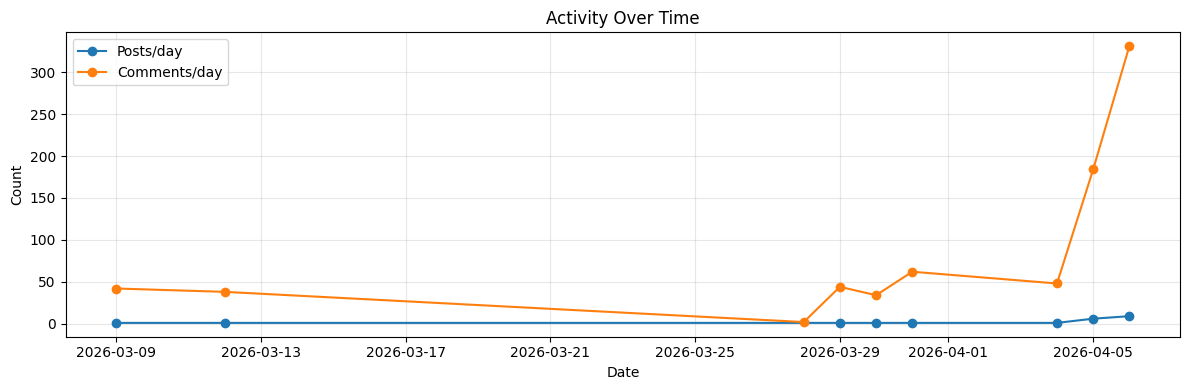

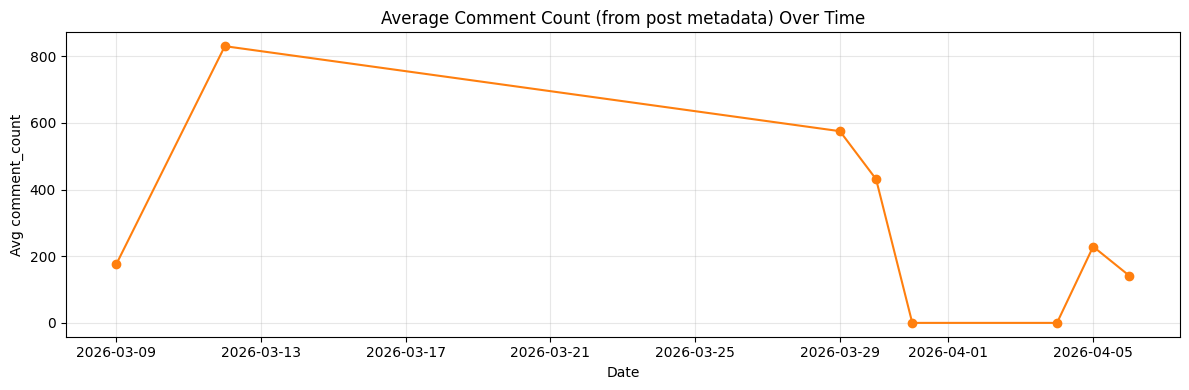

Quick read:
- Higher comment line than post line => discussion-heavy days
- Spikes in avg comment_count indicate unusually viral topics


In [2]:
# ---------- 1) Temporal activity overview ----------
plt.figure(figsize=(12, 4))

post_counts = posts_df.groupby("date", dropna=True).size().sort_index()
comment_counts = comments_df.groupby("date", dropna=True).size().sort_index()

plt.plot(post_counts.index, post_counts.values, marker="o", label="Posts/day")
plt.plot(comment_counts.index, comment_counts.values, marker="o", label="Comments/day")
plt.title("Activity Over Time")
plt.xlabel("Date")
plt.ylabel("Count")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Engagement proxy: average scraped comment_count per post over time
engagement = posts_df.groupby("date", dropna=True)["comment_count"].mean().sort_index()

plt.figure(figsize=(12, 4))
plt.plot(engagement.index, engagement.values, marker="o", color="tab:orange")
plt.title("Average Comment Count (from post metadata) Over Time")
plt.xlabel("Date")
plt.ylabel("Avg comment_count")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Quick read:")
print("- Higher comment line than post line => discussion-heavy days")
print("- Spikes in avg comment_count indicate unusually viral topics")

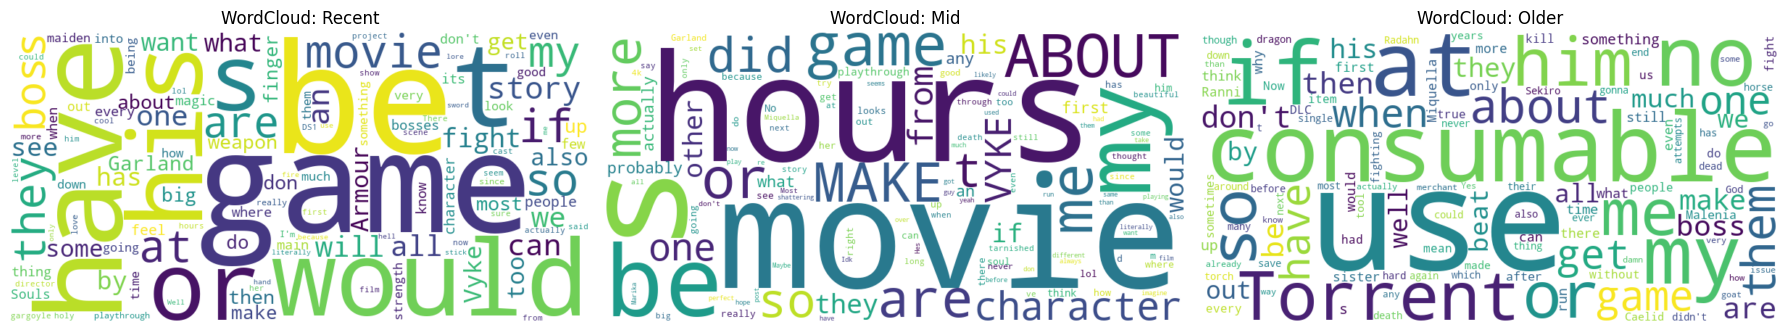

In [ ]:
# ---------- 2) Word clouds by time window ----------
# We split into recent/mid/older windows by recency from now_ref.

all_text = all_text.dropna(subset=["time"]).copy()
all_text["hours_ago"] = (now_ref - all_text["time"]).dt.total_seconds() / 3600.0

# Tertiles in recency
q1, q2 = all_text["hours_ago"].quantile([0.33, 0.66]).values

conditions = [
    all_text["hours_ago"] <= q1,
    (all_text["hours_ago"] > q1) & (all_text["hours_ago"] <= q2),
    all_text["hours_ago"] > q2,
]
labels = ["Recent", "Mid", "Older"]
all_text["time_window"] = np.select(conditions, labels, default="Unknown")

if WordCloud is None:
    print("wordcloud package is not installed. Run: pip install wordcloud")
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, w in zip(axes, labels):
        txt = " ".join(all_text.loc[all_text["time_window"] == w, "text"].tolist())
        if len(txt.strip()) == 0:
            ax.axis("off")
            ax.set_title(f"{w} (no text)")
            continue

        wc = WordCloud(
            width=800,
            height=400,
            background_color="white",
            collocations=False,
            max_words=120,
            stopwords={
                "elden",
                "ring",
                "im",
                "ive",
                "dont",
                "just",
                "like",
                "a",
                "the",
                "and",
                "to",
                "of",
                "in",
                "is",
                "that",
                "it",
                "for",
                "on",
                "with",
                "as",
                "was",
                "but",
                "you",
                "this",
                "I",
                "he",
                "she",
                "not",
                "your",
            },
        ).generate(txt)

        ax.imshow(wc, interpolation="bilinear")
        ax.axis("off")
        ax.set_title(f"WordCloud: {w}")

    plt.tight_layout()
    plt.show()

Discovered topics:
- T0: ring, elden, elden ring, ring movie, don
- T1: beautiful, freakish windy, freakish, beautiful freakish, voice
- T2: like, just, game, hours, don
- T3: movie, vyke, story, love, main


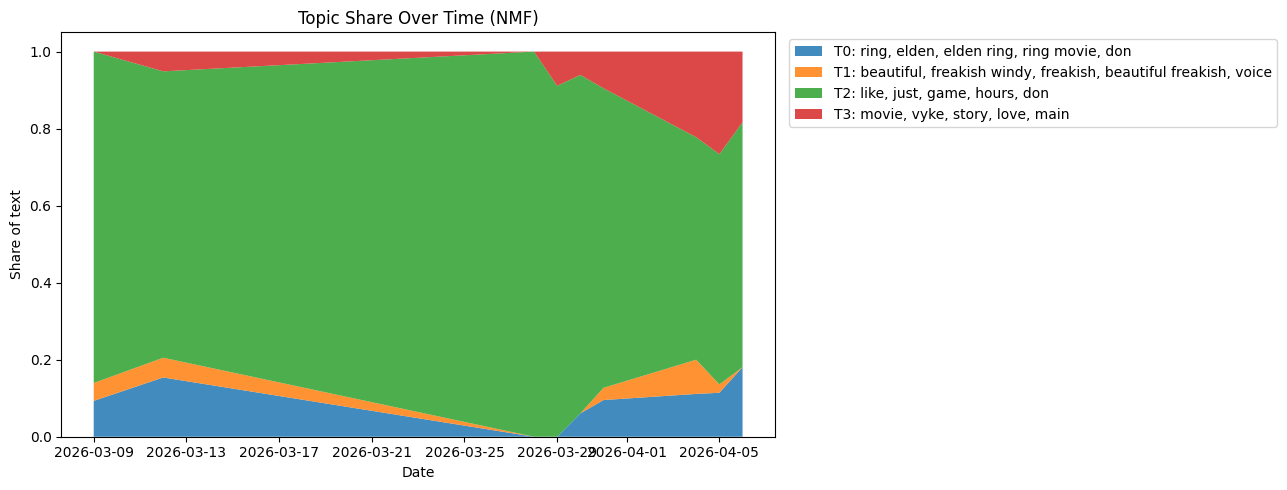

In [ ]:
# ---------- 3) Topic modelling (NMF) and topic evolution ----------
# Lightweight and reproducible topic model on combined text.

nmf_df = all_text.loc[all_text["text"].str.len() > 0].copy()

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=3000,
    ngram_range=(1, 2),
    min_df=2,
)
X = vectorizer.fit_transform(nmf_df["text"])

n_topics = 4
nmf = NMF(n_components=n_topics, random_state=42, init="nndsvda", max_iter=400)
W = nmf.fit_transform(X)
H = nmf.components_

feature_names = np.array(vectorizer.get_feature_names_out())


def top_words(topic_idx, n=8):
    idx = np.argsort(H[topic_idx])[::-1][:n]
    return ", ".join(feature_names[idx])


topic_labels = {i: f"T{i}: {top_words(i, 5)}" for i in range(n_topics)}
nmf_df["topic"] = W.argmax(axis=1)
nmf_df["topic_label"] = nmf_df["topic"].map(topic_labels)

print("Discovered topics:")
for i in range(n_topics):
    print(f"- {topic_labels[i]}")

# Topic share by day
topic_day = (
    nmf_df.dropna(subset=["date"])
    .groupby(["date", "topic_label"])
    .size()
    .reset_index(name="count")
)

topic_pivot = topic_day.pivot(
    index="date", columns="topic_label", values="count"
).fillna(0)
topic_share = topic_pivot.div(topic_pivot.sum(axis=1), axis=0)

plt.figure(figsize=(13, 5))
plt.stackplot(
    topic_share.index, topic_share.T.values, labels=topic_share.columns, alpha=0.85
)
plt.title("Topic Share Over Time (NMF)")
plt.xlabel("Date")
plt.ylabel("Share of text")
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))
plt.tight_layout()
plt.show()

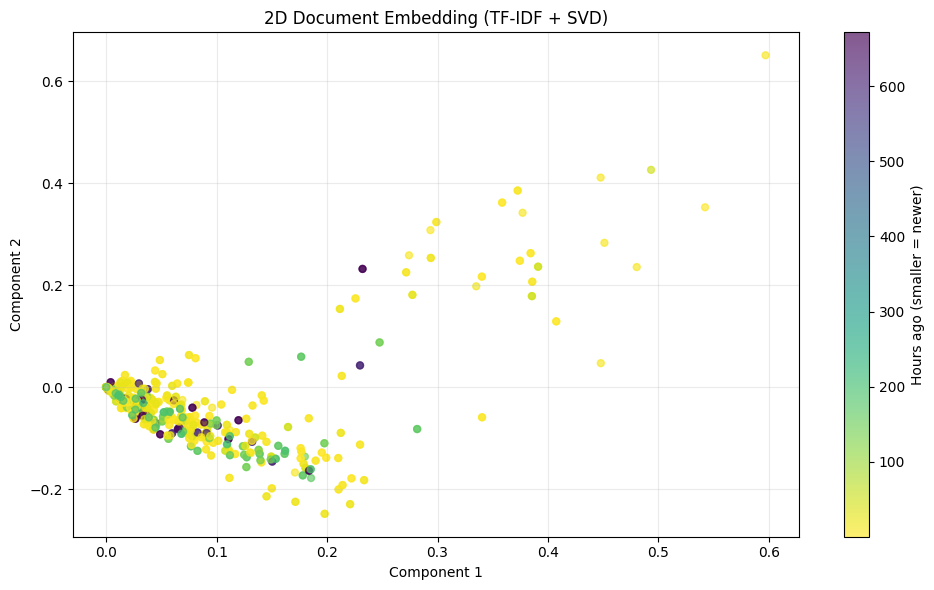

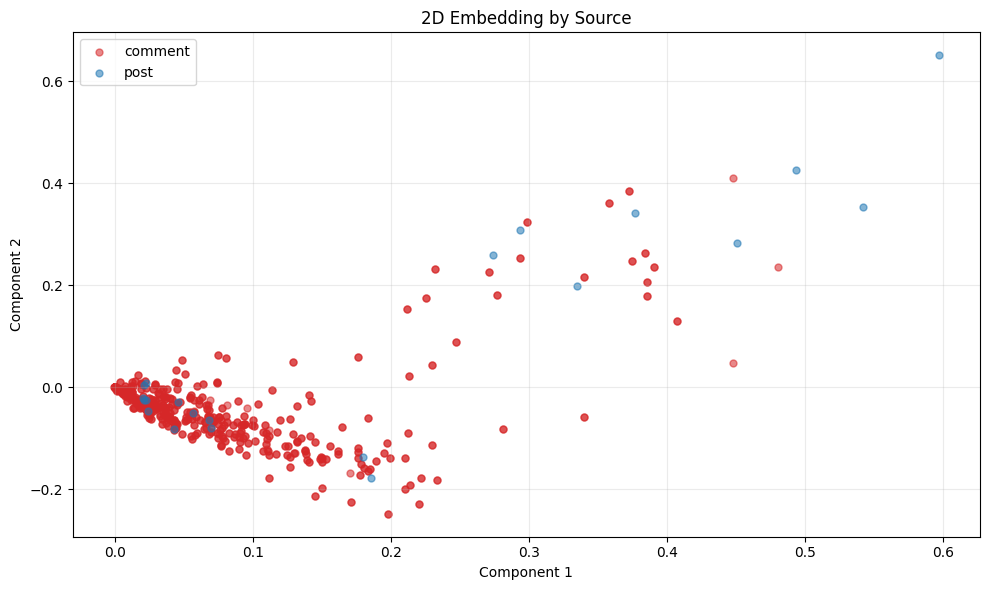

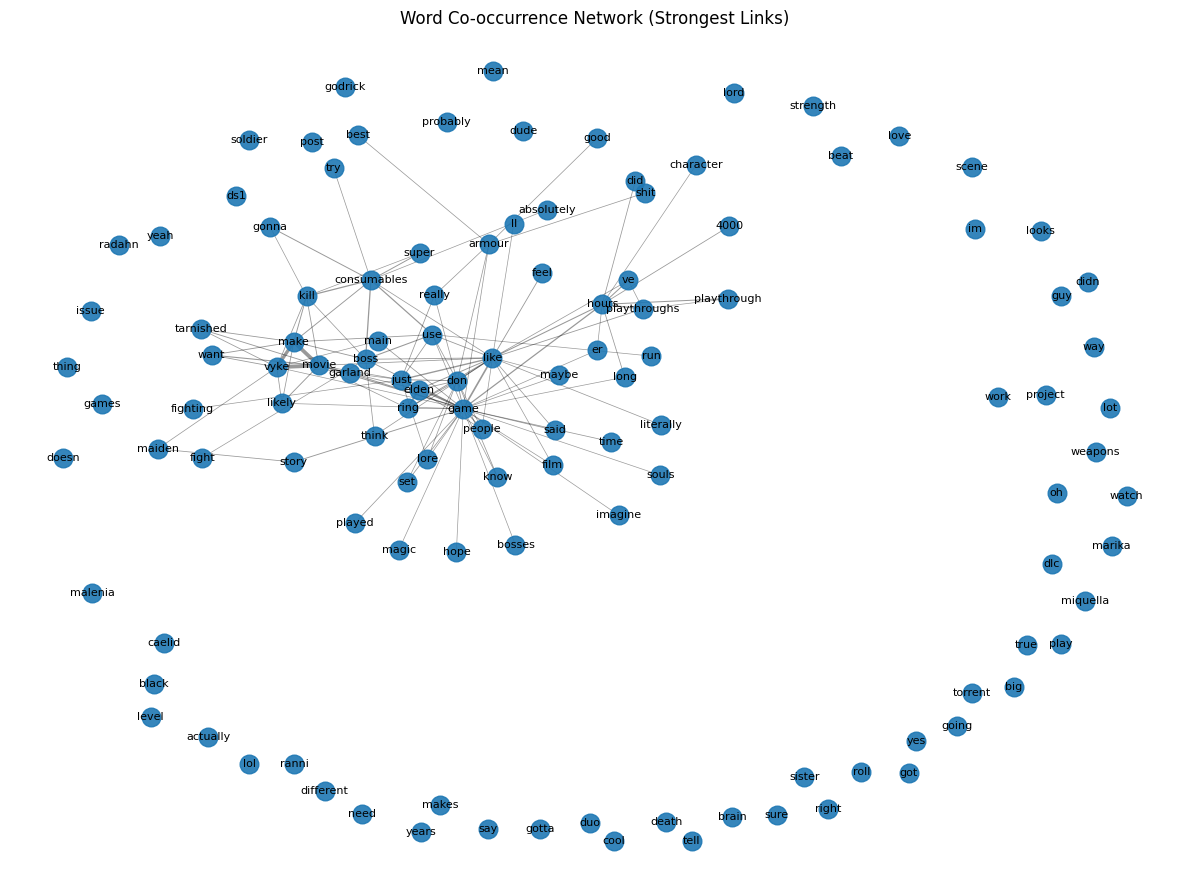

In [ ]:
# ---------- 4) Embedding projection + word network ----------
# Embeddings: TF-IDF -> SVD to 2D, colored by recency and source.

embed_vec = TfidfVectorizer(stop_words="english", max_features=2500, min_df=2)
X_embed = embed_vec.fit_transform(all_text["text"])

svd = TruncatedSVD(n_components=2, random_state=42)
coords = svd.fit_transform(X_embed)

plot_df = all_text.copy()
plot_df["x"] = coords[:, 0]
plot_df["y"] = coords[:, 1]

plt.figure(figsize=(10, 6))
sc = plt.scatter(
    plot_df["x"],
    plot_df["y"],
    c=plot_df["hours_ago"],
    cmap="viridis_r",
    alpha=0.65,
    s=25,
)
plt.colorbar(sc, label="Hours ago (smaller = newer)")
plt.title("2D Document Embedding (TF-IDF + SVD)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Same embedding by source
colors = {"post": "tab:blue", "comment": "tab:red"}
plt.figure(figsize=(10, 6))
for src, g in plot_df.groupby("source"):
    plt.scatter(g["x"], g["y"], alpha=0.55, s=25, label=src, c=colors.get(src, "gray"))

plt.title("2D Embedding by Source")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Word co-occurrence network (top words)
if nx is None:
    print("networkx package is not installed. Run: pip install networkx")
else:
    cv = CountVectorizer(stop_words="english", max_features=120, min_df=3)
    Xc = cv.fit_transform(all_text["text"])
    vocab = np.array(cv.get_feature_names_out())

    # Co-occurrence matrix
    co = (Xc.T @ Xc).toarray().astype(float)
    np.fill_diagonal(co, 0)

    # Keep strongest links
    threshold = np.quantile(co[co > 0], 0.94) if np.any(co > 0) else 0

    G = nx.Graph()
    for i in range(len(vocab)):
        G.add_node(vocab[i])

    for i in range(len(vocab)):
        for j in range(i + 1, len(vocab)):
            w = co[i, j]
            if w >= threshold and w > 0:
                G.add_edge(vocab[i], vocab[j], weight=w)

    if G.number_of_edges() == 0:
        print("No strong co-occurrence edges found with current threshold.")
    else:
        plt.figure(figsize=(12, 9))
        pos = nx.spring_layout(G, seed=42, k=0.8)
        edge_w = [
            0.3
            + 2.5 * (d["weight"] / max(nx.get_edge_attributes(G, "weight").values()))
            for _, _, d in G.edges(data=True)
        ]
        nx.draw_networkx_nodes(G, pos, node_size=180, alpha=0.9)
        nx.draw_networkx_edges(G, pos, width=edge_w, alpha=0.4)
        nx.draw_networkx_labels(G, pos, font_size=8)
        plt.title("Word Co-occurrence Network (Strongest Links)")
        plt.axis("off")
        plt.tight_layout()
        plt.show()

[nltk_data] Error loading vader_lexicon: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


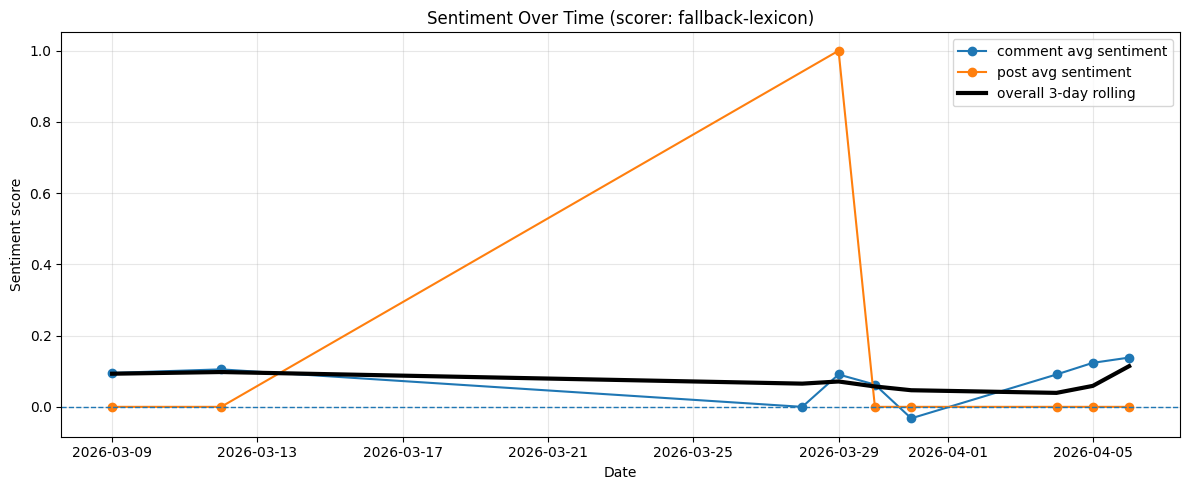


AUTO SUMMARY: WHAT CHANGES OVER TIME?
1) Activity trend: posts are up, comments are up across the observed window.
2) Peak posting day: 2026-04-06 00:00:00; peak commenting day: 2026-04-06 00:00:00.
3) Mean sentiment is 0.106 (positive-leaning).
4) Most frequent recent topics:
   - T2: like, just, game, hours, don (62.9%)
   - T3: movie, vyke, story, love, main (20.6%)
5) Use the word clouds + network to interpret vocabulary drift and recurring discussion clusters.


In [ ]:
# ---------- 5) Sentiment over time + auto-insight summary ----------
# Try VADER first; fallback to a small lexicon score if unavailable.


def build_sentiment_scorer():
    try:
        from nltk.sentiment import SentimentIntensityAnalyzer
        import nltk

        try:
            _ = SentimentIntensityAnalyzer()
        except Exception:
            nltk.download("vader_lexicon", quiet=True)

        sia = SentimentIntensityAnalyzer()
        return lambda t: float(sia.polarity_scores(str(t))["compound"]), "vader"
    except Exception:
        pos_words = {
            "good",
            "great",
            "love",
            "amazing",
            "fun",
            "best",
            "beautiful",
            "win",
            "cool",
            "nice",
            "awesome",
            "congrats",
        }
        neg_words = {
            "bad",
            "hate",
            "worst",
            "terrible",
            "awful",
            "boring",
            "lose",
            "angry",
            "pain",
            "stupid",
            "broken",
        }

        def fallback_score(t):
            toks = re.findall(r"[a-zA-Z']+", str(t).lower())
            if not toks:
                return 0.0
            p = sum(1 for w in toks if w in pos_words)
            n = sum(1 for w in toks if w in neg_words)
            return (p - n) / max(1, p + n)

        return fallback_score, "fallback-lexicon"


score_fn, score_name = build_sentiment_scorer()
all_text["sentiment"] = all_text["text"].apply(score_fn)

sent_day = (
    all_text.dropna(subset=["date"])
    .groupby(["date", "source"])["sentiment"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 5))
for src, g in sent_day.groupby("source"):
    g = g.sort_values("date")
    plt.plot(g["date"], g["sentiment"], marker="o", label=f"{src} avg sentiment")

overall = (
    all_text.dropna(subset=["date"]).groupby("date")["sentiment"].mean().sort_index()
)
rolling = overall.rolling(window=3, min_periods=1).mean()
plt.plot(
    rolling.index,
    rolling.values,
    linewidth=3,
    color="black",
    label="overall 3-day rolling",
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.title(f"Sentiment Over Time (scorer: {score_name})")
plt.xlabel("Date")
plt.ylabel("Sentiment score")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --------- Small automatic written summary ---------
print("\n" + "=" * 70)
print("AUTO SUMMARY: WHAT CHANGES OVER TIME?")
print("=" * 70)

if len(post_counts) > 1:
    growth_posts = post_counts.iloc[-1] - post_counts.iloc[0]
    trend_posts = "up" if growth_posts > 0 else "down" if growth_posts < 0 else "flat"
else:
    trend_posts = "unclear"

if len(comment_counts) > 1:
    growth_comments = comment_counts.iloc[-1] - comment_counts.iloc[0]
    trend_comments = (
        "up" if growth_comments > 0 else "down" if growth_comments < 0 else "flat"
    )
else:
    trend_comments = "unclear"

peak_day_comments = comment_counts.idxmax() if len(comment_counts) else None
peak_day_posts = post_counts.idxmax() if len(post_counts) else None
mean_sent = all_text["sentiment"].mean()

dominant_topics_recent = (
    nmf_df[nmf_df["time_window"] == "Recent"]["topic_label"]
    .value_counts(normalize=True)
    .head(2)
    if "time_window" in nmf_df.columns
    else pd.Series(dtype=float)
)

print(
    f"1) Activity trend: posts are {trend_posts}, comments are {trend_comments} across the observed window."
)
print(
    f"2) Peak posting day: {peak_day_posts}; peak commenting day: {peak_day_comments}."
)
print(
    f"3) Mean sentiment is {mean_sent:.3f} ({'positive-leaning' if mean_sent > 0.05 else 'negative-leaning' if mean_sent < -0.05 else 'mostly neutral'})."
)

if len(dominant_topics_recent) > 0:
    print("4) Most frequent recent topics:")
    for lbl, share in dominant_topics_recent.items():
        print(f"   - {lbl} ({share:.1%})")

print(
    "5) Use the word clouds + network to interpret vocabulary drift and recurring discussion clusters."
)